#imports

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

# config

In [7]:
ASSET    = "AAPL"
INTERVAL = "1h"
MLFLOW_URI = "http://localhost:5000"

# load data

In [8]:
train_df = pd.read_parquet(f'../../../data/processed/train_{ASSET.lower()}_{INTERVAL}.parquet')
test_df  = pd.read_parquet(f'../../../data/processed/test_{ASSET.lower()}_{INTERVAL}.parquet')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Train period: {train_df.index.min()} -> {train_df.index.max()}")
print(f"Test period : {test_df.index.min()} -> {test_df.index.max()}")

Train shape : (2777, 31)
Test shape  : (695, 31)
Train period: 2024-05-13 16:30:00 -> 2025-12-15 20:30:00
Test period : 2025-12-16 14:30:00 -> 2026-05-11 18:30:00


# split features and targets

In [9]:
y_train = train_df['target_direction']
X_train = train_df.drop(columns=['target_1h', 'target_direction'], errors='ignore')

y_test  = test_df['target_direction']
X_test  = test_df.drop(columns=['target_1h', 'target_direction'], errors='ignore')

print(f"Number of features: {X_train.shape[1]}")
print(f"Features: {list(X_train.columns)}")


Number of features: 29
Features: ['rsi_14', 'roc_10', 'roc_20', 'stoch_k', 'stoch_d', 'bb_percentage', 'volume_ratio', 'returns_1p', 'returns_5p', 'returns_10p', 'returns_20p', 'log_returns', 'hl_ratio', 'close_position', 'sma_7_dist', 'sma_30_dist', 'sma_50_dist', 'sma_100_dist', 'sma_200_dist', 'ema_12_dist', 'ema_26_dist', 'ema_50_dist', 'ema_200_dist', 'vwap_dist', 'macd_pct', 'macd_sig_pct', 'macd_hist_pct', 'atr_pct', 'volatility_pct']


# mlflow 

In [10]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(f"{ASSET}_{INTERVAL}_XGBoost")
mlflow.xgboost.autolog(disable=True)
print("ok")

ok


# run with mlflow

In [11]:
with mlflow.start_run(run_name=f"{ASSET}_XGBoost_Baseline"):

    baseline_model = xgb.XGBClassifier(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 5,
        eval_metric   = 'logloss',
        random_state  = 42
    )

    baseline_model.fit(X_train, y_train)
    y_pred       = baseline_model.predict(X_test)
    baseline_acc = accuracy_score(y_test, y_pred)

    mlflow.log_params({
        "n_estimators": 100, "learning_rate": 0.1,
        "max_depth": 5, "asset": ASSET, "interval": INTERVAL
    })
    mlflow.log_metric("test_accuracy", baseline_acc)

    print(f"\n--- {ASSET} Baseline Complete ---")
    print(f"Test Accuracy: {baseline_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


--- AAPL Baseline Complete ---
Test Accuracy: 0.5338

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.42      0.48       360
           1       0.51      0.65      0.57       335

    accuracy                           0.53       695
   macro avg       0.54      0.54      0.53       695
weighted avg       0.54      0.53      0.53       695

🏃 View run AAPL_XGBoost_Baseline at: http://localhost:5000/#/experiments/15/runs/d5268c03ce3d432fa377761e2e391085
🧪 View experiment at: http://localhost:5000/#/experiments/15


# feature importance

Top 15 Features for AAPL:
   1. ema_50_dist: 0.0484
   2. sma_30_dist: 0.0467
   3. sma_50_dist: 0.0449
   4. returns_1p: 0.0426
   5. ema_26_dist: 0.0421
   6. ema_200_dist: 0.0419
   7. sma_100_dist: 0.0419
   8. macd_sig_pct: 0.0416
   9. sma_7_dist: 0.0416
  10. macd_hist_pct: 0.0408
  11. bb_percentage: 0.0406
  12. macd_pct: 0.0405
  13. atr_pct: 0.0402
  14. ema_12_dist: 0.0400
  15. roc_20: 0.0394


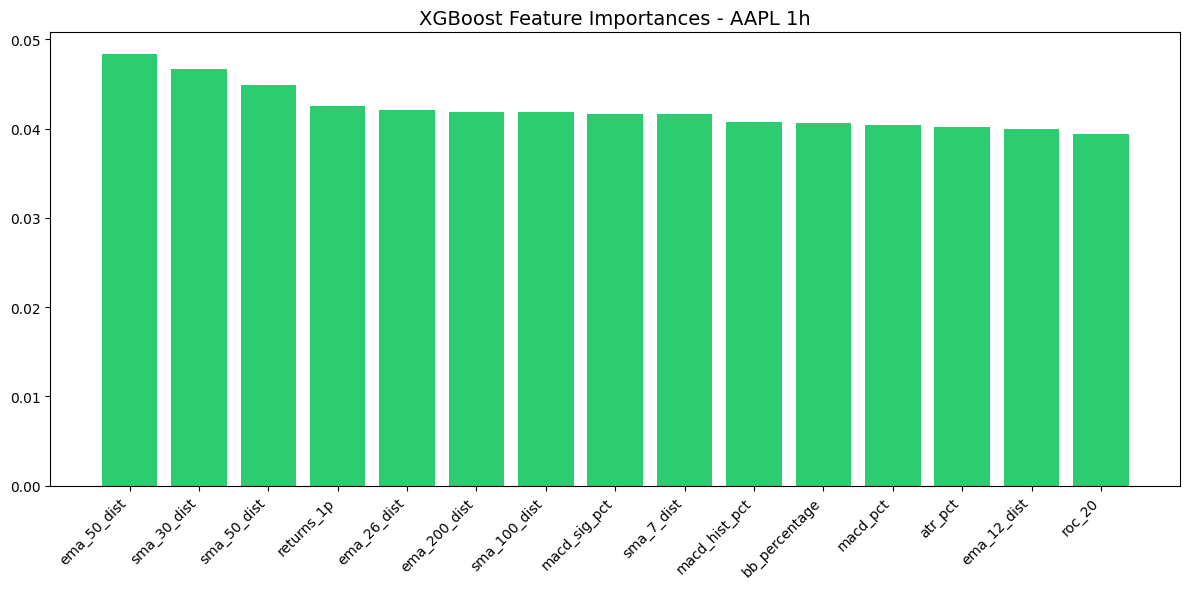

In [12]:
importances  = baseline_model.feature_importances_
feature_names = X_train.columns
indices      = np.argsort(importances)[::-1]

print(f"Top 15 Features for {ASSET}:")
for rank in range(min(15, len(feature_names))):
    fname = feature_names[indices[rank]]
    score = importances[indices[rank]]
    print(f"  {rank+1:2d}. {fname}: {score:.4f}")

plt.figure(figsize=(12, 6))
plt.title(f"XGBoost Feature Importances - {ASSET} {INTERVAL}", fontsize=14)
plt.bar(range(15), importances[indices][:15], align="center", color="#2ecc71")
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()